# Inference Speedup

## Seminar

Some functions, classes and variables required for the homework part are defined in the seminar's code.

In [ ]:
import time
from typing import List
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
import torch.nn as nn

import triton
import triton.language as tl

print("torch version:", torch.__version__)
print("triton version:", triton.__version__)

from transformers import AutoModelForCausalLM, AutoTokenizer, TextStreamer

torch version: 2.10.0+cu128
triton version: 3.6.0


/workspace/efdl_hw/week09_inference_algorithms/homework/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Catch activation and weight

In [ ]:
model_name = "Qwen/Qwen2.5-3B-Instruct"

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
    device_map="auto"
)
tokenizer = AutoTokenizer.from_pretrained(model_name)
streamer = TextStreamer(tokenizer, skip_prompt=True)

In [ ]:
# challenging input
prompt = """
# SYSTEM PREAMBLE
1) You are an excellent Python software developer with over 10 years of experience. You have a strong understanding of Python related topics, data structures, libraries, frameworks, algorithms, best practices and optimization techniques.
2) You are here to help the user (the software developer) by breaking his request in ## TASK into logical steps and writing high-quality and efficient code to implement each step.
3) You have to return the entire code.
4) Follow "Answering rules" without exception.

## ANSWERING RULES
1) Repeat the question before answering it.
2) Always follow "CHAIN OF THOUGHTS" to execute the task.

## CHAIN OF THOUGHTS
1) **OBEY the EXECUTION MODE**
2) **TASK ANALYSIS:**
   - Understand the user's request thoroughly.
   - Identify the key components and requirements of the task.
3) **PLANNING: CODDING:**
   - Break down the task into logical, sequential steps.
   - Outline the strategy for implementing each step.
4) **CODING:**
   - Explain your thought process before writing any code.
   - Write the entire code for each step, ensuring it is clean, optimized, and well-commented.
   - Handle edge cases and errors appropriately.
5) **VERIFICATION:**
   - Review the complete code solution for accuracy and efficiency.
   - Ensure the code meets all requirements and is free of errors.

## TASK

Write a python function that receives the following JSON as input and enters data from it into the Google Sheet.

{
    'date': '31-05-2024',
    'revenue': 90000,
    'person' : 'User1',
    'expensesList': [30000, 14000, 10000, 2000, 15000],
    'expensesDescList': [ 'Ключи', 'Ключи2', 'Счет за такси', 'Клей, пластины', 'Провод 40м'],
    'expensesTypeList': ['Закупки', 'Закупки', 'Расходы', 'Ремонт', 'Ремонт']
}

There is a date in JSON, you can use it to determine the month.
The data is entered into a list with the name of the month. If such a list does not exist yet, then you need to create a list with a new month inside the sheet.

The list should have the following columns (the first rows are used as headings):
A1: Дата расхода,
B1: сумма расхода,
C1: описание расхода,
D1: тип расхода,
E1: кто внес данные

G1: Дата выручки
H1: Сумма выручки
I1: Кто внес данные

Please separate expenses and profits with a blank column.
Please sort expenses by date, including those already listed in Google sheet list.
Please sort earnings by date, including those already listed in Google sheet list.

It is prohibited to use oauth2client as it is deprecated.
"""

In [ ]:
messages = [
    {"role": "system", "content": "You are Qwen, created by Alibaba Cloud. You are a helpful assistant."},
    {"role": "user", "content": prompt}
]
text = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)
model_inputs = tokenizer([text], return_tensors="pt").to(model.device)
generation_output = model.generate(**model_inputs, streamer=streamer, max_new_tokens=1024)

In [ ]:
class Catcher(nn.Module):
    def __init__(self, inps: List, module: nn.Module):
        super().__init__()
        self.backup = module
        self.inps = inps

    def forward(self, inp, **kwargs):
        self.inps.append(inp.to("cpu"))
        raise ValueError

In [ ]:
layer = model.model.layers[0]
inps = []
layer.self_attn.q_proj = Catcher(inps, layer.self_attn.q_proj) # wrap

In [ ]:
try:
    model(model_inputs.input_ids)
except ValueError as e:
    layer.self_attn.q_proj = layer.self_attn.q_proj.backup

In [ ]:
inps[0].shape

In [ ]:
weight = layer.self_attn.q_proj.weight # unwrap

### Triton GeMM

#### When to Use Triton
- Optimization Steps:
1. Use torch.compile():
    - Start by using torch.compile() to optimize your code.
2. Adapt Your Code:
    - Rewrite code to be more suitable for torch.compile().
        - E.g., eliminate graph breaks to enable CUDA graphs.
3. Profile and Identify Bottlenecks:
    - Find slow parts of your code using profiling tools.
    - Write custom Triton kernels for these parts.
4. Consider CUDA:
    - If still not fast enough, write custom CUDA kernels.

**Note**: For maximum performance from the start, you may choose CUDA directly.

#### Rough Edges in Triton
- New-ish Project:
    - Contains rough edges; code may not behave as expected.
    - Expected to become more polished over time.
- Recommendation:
    - Debugging is important; use “simulator mode” when possible.
    - Be aware of limitations on older GPUs or with certain operations.

Resources (most useful):
- [GPU MODE Lecture 14: Practitioners Guide to Triton](https://christianjmills.com/posts/cuda-mode-notes/lecture-014/#auto-tuning) – basic description about development on Triton, its pros and cons, practical examples with elaborated comments and something about optimization.
- [Flash-Decoding for long-context inference](https://pytorch.org/blog/flash-decoding/) – description of SPLIT_K optimization for fasted inference at autoregressive decoding stage due to better GPU utilization.

Less useful, but interesting:
- [Deep Dive on the Hopper TMA Unit for FP8 GEMMs](https://pytorch.org/blog/hopper-tma-unit/) – importance of TMA unit for Hopper and BlackWell.
- [Persistent Matmul](https://triton-lang.org/main/getting-started/tutorials/09-persistent-matmul.html) – special version of GeMM for Hopper and BlackWell with TMA support.


In [ ]:
def is_cuda():
    return triton.runtime.driver.active.get_current_target().backend == "cuda"

assert is_cuda(), "CUDA only tutorial"
ref_lib = 'cuBLAS'

In [ ]:
def get_cuda_autotune_config():
    return [
        triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=3, num_warps=8),
        triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 32,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5, num_warps=2),
        triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 32,  'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5, num_warps=2),
	    triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32,  'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
	    triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64,  'GROUP_SIZE_M': 8}, num_stages=3, num_warps=8),
	    triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=2, num_warps=4),
	    triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32,  'GROUP_SIZE_M': 16}, num_stages=4, num_warps=4),
	    triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64,  'GROUP_SIZE_M': 16}, num_stages=3, num_warps=8),
	    triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 16}, num_stages=2, num_warps=4),
	    triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64,  'GROUP_SIZE_M': 16}, num_stages=4, num_warps=4),
	    triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 16}, num_stages=3, num_warps=8),
	    triton.Config({'SPLIT_K': 1, 'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 256, 'GROUP_SIZE_M': 16}, num_stages=2, num_warps=4),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 64, 'GROUP_SIZE_M': 8}, num_stages=3, num_warps=8),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 128, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 128, 'BLOCK_SIZE_N': 32,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 64,  'BLOCK_SIZE_N': 32,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5, num_warps=2),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 32,  'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5, num_warps=2),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32,  'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
		triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64,  'GROUP_SIZE_M': 8}, num_stages=3, num_warps=8),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 8}, num_stages=2, num_warps=4),
		triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 32,  'GROUP_SIZE_M': 16}, num_stages=4, num_warps=4),
		triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64,  'GROUP_SIZE_M': 16}, num_stages=3, num_warps=8),
		triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 16}, num_stages=2, num_warps=4),
		triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 64,  'GROUP_SIZE_M': 16}, num_stages=4, num_warps=4),
		triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 64, 'BLOCK_SIZE_N': 64, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 16}, num_stages=3, num_warps=8),
		triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 32, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 256, 'GROUP_SIZE_M': 16}, num_stages=2, num_warps=4),
        # custom
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 16,  'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 16,  'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5, num_warps=2),
        triton.Config({'SPLIT_K': 2, 'BLOCK_SIZE_M': 16, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 16}, num_stages=2, num_warps=4),
        triton.Config({'SPLIT_K': 4, 'BLOCK_SIZE_M': 16, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 256, 'GROUP_SIZE_M': 16}, num_stages=2, num_warps=4),
        triton.Config({'SPLIT_K': 4, 'BLOCK_SIZE_M': 16,  'BLOCK_SIZE_N': 256, 'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=4, num_warps=4),
        triton.Config({'SPLIT_K': 4, 'BLOCK_SIZE_M': 16,  'BLOCK_SIZE_N': 64,  'BLOCK_SIZE_K': 32, 'GROUP_SIZE_M': 8}, num_stages=5, num_warps=2),
        triton.Config({'SPLIT_K': 4, 'BLOCK_SIZE_M': 16, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 128, 'GROUP_SIZE_M': 16}, num_stages=2, num_warps=4),
        triton.Config({'SPLIT_K': 4, 'BLOCK_SIZE_M': 16, 'BLOCK_SIZE_N': 32, 'BLOCK_SIZE_K': 256, 'GROUP_SIZE_M': 16}, num_stages=2, num_warps=4),
    ]


def get_autotune_config():
    if is_cuda():
        return get_cuda_autotune_config()
    raise NotImplementedError("ooops")

In [ ]:
@triton.autotune(
    configs=get_autotune_config(),
    key=['M', 'N', 'K'],
    reset_to_zero=['c_ptr']
)
@triton.jit
def matmul_kernel(
    # Pointers to matrices
    a_ptr, b_ptr, c_ptr,
    # Matrix dimensions
    M, N, K,
    # The stride variables represent how much to increase the ptr by when moving by 1
    # element in a particular dimension. E.g. `stride_am` is how much to increase `a_ptr`
    # by to get the element one row down (A has M rows).
    stride_am, stride_ak,
    stride_bk, stride_bn,
    stride_cm, stride_cn,
    # Meta-parameters
    BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr, SPLIT_K: tl.constexpr,
):
    """Kernel for computing the matmul C = A x B.
    A has shape (M, K), B has shape (K, N) and C has shape (M, N)
    """
    # -----------------------------------------------------------
    # Map program ids `pid` to the block of C it should compute.
    # This is done in a grouped ordering to promote L2 data reuse.
    # See above `L2 Cache Optimizations` section for details.
    pid = tl.program_id(axis=0)
    pid_sp_k = tl.program_id(axis=1)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id = pid // num_pid_in_group
    first_pid_m = group_id * GROUP_SIZE_M
    group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + (pid % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m

    # ----------------------------------------------------------
    # Create pointers for the first blocks of A and B.
    # We will advance this pointer as we move in the K direction
    # and accumulate
    # `a_ptrs` is a block of [BLOCK_SIZE_M, BLOCK_SIZE_K] pointers
    # `b_ptrs` is a block of [BLOCK_SIZE_K, BLOCK_SIZE_N] pointers
    # See above `Pointer Arithmetics` section for details
    offs_am = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offs_bn = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offs_k = pid_sp_k * BLOCK_SIZE_K + tl.arange(0, BLOCK_SIZE_K)
    a_ptrs = a_ptr + (offs_am[:, None] * stride_am + offs_k[None, :] * stride_ak)
    b_ptrs = b_ptr + (offs_k[:, None] * stride_bk + offs_bn[None, :] * stride_bn)
    # -----------------------------------------------------------
    # Iterate to compute a block of the C matrix.
    # We accumulate into a `[BLOCK_SIZE_M, BLOCK_SIZE_N]` block
    # of fp32 values for higher accuracy.
    # `accumulator` will be converted back to fp16 after the loop.
    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
    for k in range(0, tl.cdiv(K, BLOCK_SIZE_K * SPLIT_K)):
        # Load the next block of A and B, generate a mask by checking the K dimension.
        # If it is out of bounds, set it to 0.
        a = tl.load(a_ptrs, mask=offs_k[None, :] < K - k * BLOCK_SIZE_K * SPLIT_K, other=0.0)
        b = tl.load(b_ptrs, mask=offs_k[:, None] < K - k * BLOCK_SIZE_K * SPLIT_K, other=0.0)
        # We accumulate along the K dimension.
        accumulator += tl.dot(a, b, allow_tf32=False)
        # Advance the ptrs to the next K block.
        a_ptrs += BLOCK_SIZE_K * SPLIT_K * stride_ak
        b_ptrs += BLOCK_SIZE_K * SPLIT_K * stride_bk
    # You can fuse arbitrary activation functions here
    # while the accumulator is still in FP32!
    c = accumulator.to(c_ptr.dtype.element_ty)
    # -----------------------------------------------------------
    # Write back the block of the output matrix C with masks.
    offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    c_ptrs = c_ptr + stride_cm * offs_cm[:, None] + stride_cn * offs_cn[None, :]
    c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
    if SPLIT_K == 1:
        tl.store(c_ptrs, c, mask=c_mask)
    else:
        tl.atomic_add(c_ptrs, c, mask=c_mask)

In [ ]:
def matmul(a, b):
    # Check constraints.
    assert a.shape[1] == b.shape[0], "Incompatible dimensions"
    M, K = a.shape
    K, N = b.shape
    # Allocates output.
    c = torch.zeros((M, N), device=a.device, dtype=torch.float16)
    grid = lambda META: (
        triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']),
        META['SPLIT_K'],
    )
    matmul_kernel[grid](
        a, b, c,
        M, N, K,
        a.stride(0), a.stride(1),
        b.stride(0), b.stride(1),
        c.stride(0), c.stride(1),
    )
    return c

Sanity check on quality:

In [ ]:
torch.manual_seed(0)

a = inps[0][0].to(torch.float16).cuda()
b = weight.to(torch.float16).cuda()

triton_output = matmul(a, b)
torch_output = torch.matmul(a, b)

if torch.allclose(triton_output, torch_output, atol=2e-2):
    print("✅ Triton and Torch match")
else:
    print("❌ Triton and Torch differ")
    print(f"triton_output_with_fp16_inputs={triton_output}")
    print(f"torch_output_with_fp16_inputs={torch_output}")
    assert False, "Check quality"

In [ ]:
seqlen = inps[0].shape[1]
hidden_size = inps[0].shape[2]
seqlen, hidden_size


def prepare_a(M: int):
    inp = inps[0][0]
    if M > seqlen:
        n_repeats = M // seqlen + 1
        return inp.repeat(n_repeats, 1)[:M]
    else:
        return inp[:M]


def benchmark(M, provider, provider_funcs):
    N = weight.shape[0]
    K = weight.shape[1]

    a = prepare_a(M).to(torch.float16).cuda()
    b = weight.T.to(torch.float16)
    assert a.shape == (M, K), f"{a.shape} != {(M, K)}"
    assert b.shape == (K, N), b.shape

    quantiles = [0.5, 0.2, 0.8]
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: provider_funcs[provider](a, b), quantiles=quantiles)
    perf = lambda ms: ms # TFlops = 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)


In [ ]:
configs = [
    triton.testing.Benchmark(
        x_names=["M"],  # Argument names to use as an x-axis for the plot
        x_vals=[2 ** i for i in range(7)],  # Different possible values for `x_name`
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        # Possible values for `line_arg`
        line_vals=[ref_lib.lower(), "triton"],  # Label name for the lines
        line_names=[ref_lib, "Triton"],  # Line styles
        styles=[("green", "-"), ("blue", "-")],
        ylabel="ms",  # Label name for the y-axis
        plot_name="GeMV-performance-" + ("fp16"),  # Name for the plot, used also as a file name for saving the plot.
        args={"provider_funcs": {"triton": matmul, "cublas": torch.matmul}},
    ),
    triton.testing.Benchmark(
        x_names=["M"],  # Argument names to use as an x-axis for the plot
        x_vals=[1024 * i for i in range(4, 21)],  # Different possible values for `x_name`
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        # Possible values for `line_arg`
        line_vals=[ref_lib.lower(), "triton"],  # Label name for the lines
        line_names=[ref_lib, "Triton"],  # Line styles
        styles=[("green", "-"), ("blue", "-")],
        ylabel="ms",  # Label name for the y-axis
        plot_name="GeMM-performance-" + ("fp16"),  # Name for the plot, used also as a file name for saving the plot.
        args={"provider_funcs": {"triton": matmul, "cublas": torch.matmul}},
    ),
]


triton.testing.perf_report(configs)(benchmark).run(show_plots=True, print_data=True)

## HW    (10 points total, 4 bonus points)

### Dynamic W8A8 GeMM (6 points)

> **Important disclaimer:** please do the assignment in Google Colab on Nvidia Tesla T4 GPU -- it has all the required dependecies pre-installed and will save you lots of time.

For the disobedient: on other GPU types (H100) the code will need to be significantly rewritten to account for architectural features for maximum performance (see "less useful but interesting" above in the seminar).

> **Important disclaimer 2:** to complete the homework, you need to run the seminar code above, it contains the necessary helper functions.

Useful resources:
- [Matrix Multiplication Background User's Guide](https://docs.nvidia.com/deeplearning/performance/dl-performance-matrix-multiplication/index.html)
- [Deep Dive on CUTLASS Ping-Pong GEMM Kernel](https://pytorch.org/blog/cutlass-ping-pong-gemm-kernel/)
- [Accelerating 2D Dynamic Block Quantized Float8 GEMMs in Triton](https://pytorch.org/blog/accelerating-gemms-triton/)

![](https://habrastorage.org/webt/xq/r5/8a/xqr58aw0gd6tdm-j45yqad67w1a.png)

#### Quantization kernel (2 points)

In this task you will need to implement fast quantization operation in per-row mode:
1. You need to fill in the gaps marked with `YOUR CODE HERE`, please do not delete these comments with the task and marking as it makes checking easier
2. Next to each gap there is a comment with `# !!! TASK: ...` that will help understand what exactly needs to be written
3. The illustration above shows exactly which dimensions are used to calculate scales for activation and weight matrices
4. The formula is `scales = tensor.abs().max(axis=axis) / INT8_max_value`

In [ ]:
@triton.autotune(
    configs=[
        triton.Config({}, num_stages=2, num_warps=8),
        triton.Config({}, num_stages=2, num_warps=4),
        triton.Config({}, num_stages=2, num_warps=2),
        triton.Config({}, num_stages=2, num_warps=1),
     ],
    key=['K'],
)
@triton.jit
def quantize_int8_perrow_kernel(
    fpa_ptr, a_ptr, as_ptr,
    M, K,
    stride_fpam, stride_fpak,
    stride_am, stride_ak,
    stride_asm,
    # Meta-parameters
    BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,
):
    pid_m = tl.program_id(axis=0)
    offs_k = tl.arange(0, BLOCK_SIZE_K)
    offs_am = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M

    INT8_MAX_VALUE = 127

    fpa_ptrs = fpa_ptr + offs_am[:, None] * stride_fpam + offs_k[None, :] * stride_fpak
    a_ptrs = a_ptr + offs_am[:, None] * stride_am + offs_k[None, :] * stride_ak
    a_max = tl.zeros((BLOCK_SIZE_M,), dtype=tl.float32)
    for k in range(0, tl.cdiv(K, BLOCK_SIZE_K)):
        fpa = tl.load(fpa_ptrs, mask=offs_k[None, :] < K - k * BLOCK_SIZE_K, other=0.0)

        # !!! TASK: calc maximum absolute value of each row of fpa and update a_max
        # YOUR CODE HERE
        a_max = tl.maximum(a_max, tl.max(tl.abs(fpa), axis=1))
        # YOUR CODE HERE

        fpa_ptrs += BLOCK_SIZE_K * stride_fpak

    # !!! TASK: divide a_max by max positive INT8 value
    # YOUR CODE HERE
    a_scale = a_max / INT8_MAX_VALUE
    # YOUR CODE HERE

    fpa_ptrs = fpa_ptr + offs_am[:, None] * stride_fpam + offs_k[None, :] * stride_fpak
    for k in range(0, tl.cdiv(K, BLOCK_SIZE_K)):
        fpa = tl.load(fpa_ptrs, mask=offs_k[None, :] < K - k * BLOCK_SIZE_K, other=0.0)

        # !!! TASK: divide fpa by a_scale and convert to INT8
        # YOUR CODE HERE
        inta = tl.cast(fpa / a_scale[:, None], tl.int8)
        # inta = t.to(torch.int8)
        # YOUR CODE HERE

        tl.store(a_ptrs, inta, mask=offs_k[None, :] < K - k * BLOCK_SIZE_K)
        fpa_ptrs += BLOCK_SIZE_K * stride_fpak
        a_ptrs += BLOCK_SIZE_K * stride_ak
    as_offs = pid_m * BLOCK_SIZE_M * stride_asm + tl.arange(0, BLOCK_SIZE_M)
    tl.store(as_ptr + as_offs, a_scale)


def quantize_int8_perrow(fpa):
    a = torch.empty(fpa.shape, device=fpa.device, dtype=torch.int8)
    a_scale = torch.empty(fpa.shape[0], device=fpa.device, dtype=fpa.dtype)
    M, K = fpa.shape
    BLOCK_SIZE_M = 1
    BLOCK_SIZE_K = triton.next_power_of_2(K)
    grid = (M // BLOCK_SIZE_M,)
    quantize_int8_perrow_kernel[grid](
        fpa, a, a_scale,
        M, K,
        fpa.stride(0), fpa.stride(1),
        a.stride(0), a.stride(1),
        a_scale.stride(0),
        BLOCK_SIZE_M, BLOCK_SIZE_K,
    )
    return a, a_scale


def quantize_int8(weight, axis=0, tp_rank=0):
    # Weight shape: [H1, H2]
    # Scale shape: [H2]
    
    # !!! TASK: calculate scale by taking maximum over axis and saving dims and divide on maximum positive INT8 value
    # YOUR CODE HERE
    INT8_MAX_VALUE = 127
    scale = torch.max(weight.abs(), axis=axis)[0] / INT8_MAX_VALUE
    scale = scale.unsqueeze(axis)
    # YOUR CODE HERE

    # !!! TASK: divide weight by scale and convert to int8
    # YOUR CODE HERE
    weight = torch.round(weight / scale).to(torch.int8)
    # YOUR CODE HERE

    # col major will accelerate i8xi8 kernel.
    if axis == 0:
        weight = weight.t().contiguous().t()
    scale = scale.squeeze(axis)
    return weight.contiguous().cuda(tp_rank), scale.contiguous().cuda(tp_rank)


#### Per-row W8A8 GeMM (4 points)

Next we need to implement a fast operation for per-row W8A8 GeMM:
1. To do this, you need to fill in the gaps marked with `YOUR CODE HERE`. Please do not delete these comments with the task and marking as it makes checking easier
2. Next to each gap there is a comment with `# !!! TASK: ...` that will help understand what exactly needs to be written

In [ ]:
@triton.autotune(
    configs=get_autotune_config(),
    key=['M', 'N', 'K'],
    reset_to_zero=['c_ptr']
)
@triton.jit
def perrow_w8a8_matmul_kernel(
    # Pointers to matrices
    a_ptr, as_ptr, b_ptr, bs_ptr, c_ptr,
    # Matrix dimensions
    M, N, K,
    # The stride variables represent how much to increase the ptr by when moving by 1
    # element in a particular dimension. E.g. `stride_am` is how much to increase `a_ptr`
    # by to get the element one row down (A has M rows).
    stride_am, stride_ak,
    stride_asm,
    stride_bk, stride_bn,
    stride_bsn,
    stride_cm, stride_cn,
    # Meta-parameters
    BLOCK_SIZE_M: tl.constexpr, BLOCK_SIZE_N: tl.constexpr, BLOCK_SIZE_K: tl.constexpr,
    GROUP_SIZE_M: tl.constexpr, SPLIT_K: tl.constexpr,
):
    """Kernel for computing the matmul C = A x B.
    A has shape (M, K), B has shape (K, N) and C has shape (M, N)
    """
    # -----------------------------------------------------------
    # Map program ids `pid` to the block of C it should compute.
    # This is done in a grouped ordering to promote L2 data reuse.
    # See above `L2 Cache Optimizations` section for details.
    pid = tl.program_id(axis=0)
    pid_sp_k = tl.program_id(axis=1)
    num_pid_m = tl.cdiv(M, BLOCK_SIZE_M)
    num_pid_n = tl.cdiv(N, BLOCK_SIZE_N)
    num_pid_in_group = GROUP_SIZE_M * num_pid_n
    group_id = pid // num_pid_in_group
    first_pid_m = group_id * GROUP_SIZE_M
    group_size_m = min(num_pid_m - first_pid_m, GROUP_SIZE_M)
    pid_m = first_pid_m + (pid % group_size_m)
    pid_n = (pid % num_pid_in_group) // group_size_m

    # ----------------------------------------------------------
    # Create pointers for the first blocks of A and B.
    # We will advance this pointer as we move in the K direction
    # and accumulate
    # `a_ptrs` is a block of [BLOCK_SIZE_M, BLOCK_SIZE_K] pointers
    # `b_ptrs` is a block of [BLOCK_SIZE_K, BLOCK_SIZE_N] pointers
    # See above `Pointer Arithmetics` section for details
    offs_am = (pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)) % M
    offs_bn = (pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)) % N
    offs_k = pid_sp_k * BLOCK_SIZE_K + tl.arange(0, BLOCK_SIZE_K)
    a_ptrs = a_ptr + (offs_am[:, None] * stride_am + offs_k[None, :] * stride_ak)
    b_ptrs = b_ptr + (offs_k[:, None] * stride_bk + offs_bn[None, :] * stride_bn)
    as_ptrs = as_ptr + offs_am * stride_asm
    bs_ptrs = bs_ptr + offs_bn * stride_bsn
    a_scale = tl.load(as_ptrs, mask=offs_am < M, other=0.0)
    b_scale = tl.load(bs_ptrs, mask=offs_bn < N, other=0.0)
    # -----------------------------------------------------------
    # Iterate to compute a block of the C matrix.
    # We accumulate into a `[BLOCK_SIZE_M, BLOCK_SIZE_N]` block
    # of fp32 values for higher accuracy.
    # `accumulator` will be converted back to fp16 after the loop.
    
    # !!! TASK: create accumulator of int32 dtype
    # YOUR CODE HERE
    accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.int32)
    # YOUR CODE HERE

    # !!! TASK: implement the loop over K dimension.
    # In the loop first load next blocks of A and B, using an appropriate mask over K dimension.
    # Then, multiply blocks and update the accumulator
    # Finally, update the pointers to A and B matrix.
    # You can rely on implementation of regular matmul from the seminar

    # YOUR CODE HERE
    for k in range(0, tl.cdiv(K, BLOCK_SIZE_K * SPLIT_K)):
        a = tl.load(a_ptrs, mask=offs_k[None, :] < K - k * BLOCK_SIZE_K * SPLIT_K, other=0.0)
        b = tl.load(b_ptrs, mask=offs_k[:, None] < K - k * BLOCK_SIZE_K * SPLIT_K, other=0.0)
        accumulator += tl.dot(a, b)
        a_ptrs += BLOCK_SIZE_K * SPLIT_K * stride_ak
        b_ptrs += BLOCK_SIZE_K * SPLIT_K * stride_bk
    # YOUR CODE HERE

    # You can fuse arbitrary activation functions here
    # while the accumulator is still in FP32!
    
    # !!! TASK: dequantize the accumulator with a_scale and b_scale (outer product) and convert to c_ptr.dtype.element_ty
    # YOUR CODE HERE
    
    c = tl.cast(accumulator * tl.cast(a_scale[:, None], tl.float32) * tl.cast(b_scale[None, :], tl.float32), c_ptr.dtype.element_ty)
    
    # YOUR CODE HERE

    # -----------------------------------------------------------
    # Write back the block of the output matrix C with masks.
    offs_cm = pid_m * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
    offs_cn = pid_n * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
    c_ptrs = c_ptr + stride_cm * offs_cm[:, None] + stride_cn * offs_cn[None, :]
    c_mask = (offs_cm[:, None] < M) & (offs_cn[None, :] < N)
    if SPLIT_K == 1:
        tl.store(c_ptrs, c, mask=c_mask)
    else:
        tl.atomic_add(c_ptrs, c, mask=c_mask)


def matmul_int8(a, a_scale, b, b_scale, out=None):
    # Check constraints.
    assert a.shape[1] == b.shape[0], "Incompatible dimensions"
    M, K = a.shape
    K, N = b.shape
    # Allocates output.
    if out == None:
        c = torch.zeros((M, N), device=a.device, dtype=torch.float16)
    else:
        c = out.fill_(0.)
    grid = lambda META: (
        triton.cdiv(M, META['BLOCK_SIZE_M']) * triton.cdiv(N, META['BLOCK_SIZE_N']),
        META['SPLIT_K'],
    )
    perrow_w8a8_matmul_kernel[grid](
        a, a_scale, b, b_scale, c,
        M, N, K,
        a.stride(0), a.stride(1),
        a_scale.stride(0),
        b.stride(0), b.stride(1),
        b_scale.stride(0),
        c.stride(0), c.stride(1),
    )
    return c


def matmul_quantize_int8(fpa, b, b_scale, out=None):
    # !!! TASK: quantize fpa to int8 and call matmul_int8
    # YOUR CODE HERE
    a, a_scale = quantize_int8_perrow(fpa)
    return matmul_int8(a, a_scale, b, b_scale, out)
    # YOUR CODE HERE


Sanity check (heavily relaxed for non-smoothed case):

In [ ]:
torch.manual_seed(42)
cos = torch.nn.CosineSimilarity(0)

a = inps[0][0].to(torch.float16).cuda()
b = weight.to(torch.float16).cuda()

int_a, scale_a = quantize_int8_perrow(a)
int_b, scale_b = quantize_int8(b, axis=0)


triton_output = matmul_int8(int_a, scale_a, int_b, scale_b)
torch_output = torch.matmul(a, b)

if (torch_output.float() - triton_output.float()).abs().mean() < 0.03 and torch.quantile((torch_output.float() - triton_output.float()).abs(), 0.95) < 0.07:
    print("✅ Triton FP8 and Torch match")
else:
    print("❌ Triton FP8 and Torch differ")
    print("Quantization cos: ", cos((int_a * scale_a.unsqueeze(1)).flatten().to(torch.float32), a.flatten().to(torch.float32)).item())

    print('=' * 50)
    print(f"triton_output_with_fp8={triton_output}")
    print(f"torch_output={torch_output}")

    print('=' * 50)
    print("infs in triton:", (triton_output).isinf().sum())
    print("infs in torch:", (torch_output).isinf().sum())

    print('=' * 50)
    print("Output cos:", cos(triton_output.flatten().to(torch.float32), torch_output.flatten().to(torch.float32)).item())
    print(((triton_output - torch_output).abs() >= 0.5).sum())
    print(((triton_output - torch_output).abs() / (torch_output.abs() + 1e-5)))
    assert False, "Triton and Torch differ"

✅ Triton FP8 and Torch match


Sanity checks on perf:

In [ ]:
def test_perf_quantize(M: int, K: int, iters: int = 256, thr: float = 1.3):
    torch.manual_seed(0)
    print(f"M: {M} K: {K}")

    a = torch.randn((M, K), device='cuda', dtype=torch.float16)
    # warmup
    for _ in range(10):
        int_a, a_scale = quantize_int8(a, 1)
        int_a, a_scale = quantize_int8_perrow(a)
    torch.cuda.synchronize()

    t1 = time.time()
    for _ in range(iters):
        int_a, a_scale = quantize_int8_perrow(a)
    torch.cuda.synchronize()
    t2 = time.time()
    for _ in range(iters):
        int_a, a_scale = quantize_int8(a, axis=1)
    torch.cuda.synchronize()
    t3 = time.time()

    torch_time = (t3 - t2) / iters
    triton_time = (t2 - t1) / iters

    print(f"Torch time cost: {torch_time}")
    print(f"Triton time cost: {triton_time}")
    assert torch_time / triton_time > thr, f"Must get at least {thr}x speedup"
    return triton_time, torch_time


def test_perf_matmul_int8(M, K, N, iters: int = 512, thr: float = 0.99):
    print("M: {} K: {} N: {}".format(M, K, N))
    torch.manual_seed(0)
    a = torch.randn((M, K), device='cuda', dtype=torch.float16)
    b = torch.randn((K, N), device='cuda', dtype=torch.float16).contiguous()
    int_b, scale_b = quantize_int8(b, axis=0)
    for _ in range(10):
        # int_a, a_scale = quantize_int8(a, 1)
        int_a, a_scale = quantize_int8_perrow(a)
        triton_output = matmul_int8(int_a, a_scale, int_b, scale_b)
    torch.cuda.synchronize()
    t1 = time.time()
    for _ in range(iters):
        #int_a, a_scale, _ = quantize_int8(a, 1)
        int_a, a_scale = quantize_int8_perrow(a)
    torch.cuda.synchronize()
    qt2 = time.time()
    for _ in range(iters):
        triton_output = matmul_int8(int_a, a_scale, int_b, scale_b)
    torch.cuda.synchronize()
    t2 = time.time()
    quant_time = qt2 - t1
    triton_time = t2 - qt2
    triton_tflops = 2 * M * N * K * 1e-12 / (triton_time / iters)
    quant_bandwith = 2 * M * K * 1e-9 / (quant_time / iters)
    print("Triton time cost: {} (tflops {}) + quant: {} (bandwidth {})".format(
        triton_time, triton_tflops, quant_time, quant_bandwith))
    for _ in range(10):
        torch_output = torch.matmul(a, b)
    torch.cuda.synchronize()
    iters = 512
    t1 = time.time()
    for _ in range(iters):
        torch_output = torch.matmul(a, b)
    torch.cuda.synchronize()
    t2 = time.time()
    torch_time = t2 - t1
    torch_tflops = 2 * M * N * K * 1e-12 / (torch_time / iters)
    print("Torch time cost: {} (tflops {})".format(t2 - t1, torch_tflops))

    assert torch_time / triton_time > thr, f"Must get at least {thr}x speedup"
    return triton_time, torch_time, quant_time


def test_perf_model_layer(bs, seq_len, hidden, inter, tp, thr: float = 0.99):
    st1 = 0
    st2 = 0
    st3 = 0
    t1, t2, t3 = test_perf_matmul_int8(bs * seq_len, hidden, hidden * 3 // tp, thr=thr)
    test_perf_quantize(bs * seq_len, hidden, thr=thr)
    st1 += t1
    st2 += t2
    st3 += t3
    t1, t2, t3 = test_perf_matmul_int8(bs * seq_len, hidden // tp, hidden, thr=thr)
    test_perf_quantize(bs * seq_len, hidden // tp, thr=thr)
    st1 += t1
    st2 += t2
    st3 += t3
    t1, t2, t3 = test_perf_matmul_int8(bs * seq_len, hidden, inter * 2 // tp, thr=thr)
    st1 += t1
    st2 += t2
    st3 += t3
    t1, t2, t3 = test_perf_matmul_int8(bs * seq_len, inter // tp, hidden, thr=thr)
    test_perf_quantize(bs * seq_len, inter // tp, thr=thr)
    st1 += t1
    st2 += t2
    st3 += t3
    print("Triton time {} Torch time {} Quant time {}".format(st1, st2, st3))
    assert st2 / st1 > thr, f"Must get at least {thr}x speedup"

In [ ]:
bs = 32
hidden = model.config.hidden_size
inter  = model.config.intermediate_size
prefill_len = 512
decode_len = 1
tp = 1

In [ ]:
test_perf_model_layer(bs, prefill_len, hidden, inter, tp, thr=1.3)

M: 16384 K: 2048 N: 6144
Triton time cost: 2.8687732219696045 (tflops 73.58763352791388) + quant: 0.17580270767211914 (bandwidth 195.44487580977784)
Torch time cost: 3.866551160812378 (tflops 54.59807041286834)
M: 16384 K: 2048
Torch time cost: 0.001547585241496563
Triton time cost: 0.00034384895116090775
M: 16384 K: 2048 N: 2048
Triton time cost: 0.987476110458374 (tflops 71.26121172187113) + quant: 0.17593979835510254 (bandwidth 195.29258694869657)
Torch time cost: 1.2934587001800537 (tflops 54.403549311523)
M: 16384 K: 2048
Torch time cost: 0.0015513291582465172
Triton time cost: 0.0003441404551267624
M: 16384 K: 2048 N: 22016
Triton time cost: 10.633787393569946 (tflops 71.13777734237077) + quant: 0.17587757110595703 (bandwidth 195.361683425228)
Torch time cost: 15.576223134994507 (tflops 48.56530324160349)
M: 16384 K: 11008 N: 2048
Triton time cost: 4.95505952835083 (tflops 76.33248355359905) + quant: 1.016528844833374 (bandwidth 181.68062290280875)
Torch time cost: 7.200222969055

Note: The last line should show the overall speedup per layer at the prefill stage. For Nvidia Tesla T4 and fixed library versions, our implementation is about 1.6x faster.

In [ ]:
test_perf_model_layer(bs, decode_len, hidden, inter, tp, thr=0.1)

M: 32 K: 2048 N: 6144
Triton time cost: 0.03486204147338867 (tflops 11.827100278414127) + quant: 0.02751445770263672 (bandwidth 2.439040039432394)
Torch time cost: 0.03497719764709473 (tflops 11.78816166395331)
M: 32 K: 2048
Torch time cost: 8.280575275421143e-05
Triton time cost: 5.088653415441513e-05
M: 32 K: 2048 N: 2048
Triton time cost: 0.032006025314331055 (tflops 4.294158744243077) + quant: 0.024583816528320312 (bandwidth 2.72979843966421)
Torch time cost: 0.013242959976196289 (tflops 10.378265411889881)
M: 32 K: 2048
Torch time cost: 7.887464016675949e-05
Triton time cost: 4.801061004400253e-05
M: 32 K: 2048 N: 22016
Triton time cost: 0.06650805473327637 (tflops 22.21488443391157) + quant: 0.025794506072998047 (bandwidth 2.6016727674522233)
Torch time cost: 0.12468457221984863 (tflops 11.84965167317469)
M: 32 K: 11008 N: 2048
Triton time cost: 0.03649640083312988 (tflops 20.241293882365746) + quant: 0.024563312530517578 (bandwidth 14.684914485855765)
Torch time cost: 0.06086993

Note: The last line shows the per-layer comparison at the decode stage. For the same Nvidia Tesla T4 and libraries, the speedup turned out to be much lower (x1.03). To speed up decode, a CUDA implementation is needed.

Benchmarks:

In [ ]:
@torch.no_grad()
def benchmark_quant_gemm(M, provider, provider_funcs):
    N = weight.shape[0]
    K = weight.shape[1]

    fpa = prepare_a(M).to(torch.float16).cuda().contiguous()
    fpb = weight.data.T.to(torch.float16).contiguous()
    b, b_scale = quantize_int8(fpb, axis=0)

    assert fpa.shape == (M, K), f"{fpa.shape} != {(M, K)}"
    assert b.shape == (K, N), b.shape

    quantiles = [0.5, 0.2, 0.8]
    ms, min_ms, max_ms = triton.testing.do_bench(lambda: provider_funcs[provider](fpa, fpb, b, b_scale), quantiles=quantiles)
    perf = lambda ms: ms # TFlops = 2 * M * N * K * 1e-12 / (ms * 1e-3)
    return perf(ms), perf(max_ms), perf(min_ms)

In [ ]:
provider_funcs = {
    "triton int8": lambda fpa, fpb, b, b_scale: matmul_quantize_int8(fpa, b, b_scale),
    "triton fp16": lambda fpa, fpb, b, b_scale: matmul(fpa, fpb),
    "cublas fp16": lambda fpa, fpb, b, b_scale: torch.matmul(fpa, fpb)
}

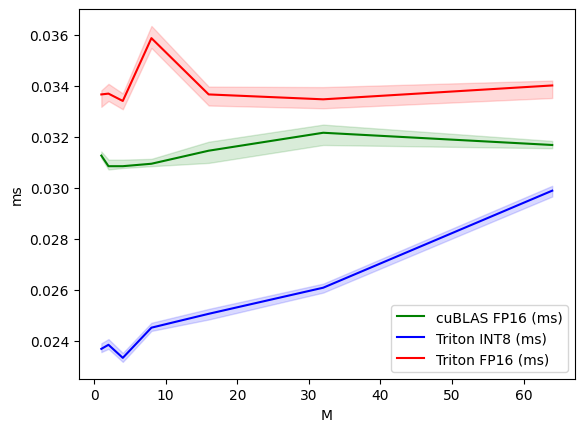

GeMV-performance-FP16 vs INT8:
      M  cuBLAS FP16 (ms)  Triton INT8 (ms)  Triton FP16 (ms)
0   1.0          0.031264          0.023680          0.033664
1   2.0          0.030848          0.023840          0.033696
2   4.0          0.030848          0.023328          0.033408
3   8.0          0.030944          0.024512          0.035872
4  16.0          0.031456          0.025056          0.033664
5  32.0          0.032160          0.026080          0.033472
6  64.0          0.031680          0.029888          0.034016


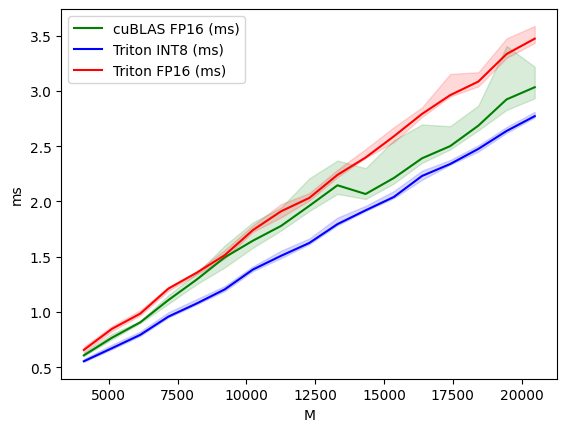

GeMM-performance-FP16 vs INT8:
          M  cuBLAS FP16 (ms)  Triton INT8 (ms)  Triton FP16 (ms)
0    4096.0          0.607424          0.554048          0.656752
1    5120.0          0.767488          0.672640          0.847744
2    6144.0          0.906336          0.793008          0.984800
3    7168.0          1.107904          0.958304          1.211504
4    8192.0          1.292576          1.076608          1.354592
5    9216.0          1.494400          1.204640          1.514208
6   10240.0          1.645328          1.384320          1.741280
7   11264.0          1.779216          1.508640          1.911376
8   12288.0          1.960416          1.624624          2.032256
9   13312.0          2.146672          1.795136          2.240848
10  14336.0          2.067744          1.920352          2.397936
11  15360.0          2.212432          2.040784          2.589504
12  16384.0          2.390688          2.230896          2.792192
13  17408.0          2.501168          2.3392

In [ ]:
configs = [
    triton.testing.Benchmark(
        x_names=["M"],  # Argument names to use as an x-axis for the plot
        x_vals=[2 ** i for i in range(7)],  # Different possible values for `x_name`
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        # Possible values for `line_arg`
        line_vals=["cublas fp16", "triton int8", "triton fp16"],  # Label name for the lines
        line_names=["cuBLAS FP16", "Triton INT8", "Triton FP16"],  # Line styles
        styles=[("green", "-"), ("blue", "-"), ("red", "-")],
        ylabel="ms",  # Label name for the y-axis
        plot_name="GeMV-performance-" + ("FP16 vs INT8"),  # Name for the plot, used also as a file name for saving the plot.
        args={"provider_funcs": provider_funcs},
    ),
    triton.testing.Benchmark(
        x_names=["M"],  # Argument names to use as an x-axis for the plot
        x_vals=[1024 * i for i in range(4, 21)],  # Different possible values for `x_name`
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        # Possible values for `line_arg`
        line_vals=["cublas fp16", "triton int8", "triton fp16"],  # Label name for the lines
        line_names=["cuBLAS FP16", "Triton INT8", "Triton FP16"],  # Line styles
        styles=[("green", "-"), ("blue", "-"), ("red", "-")],
        ylabel="ms",  # Label name for the y-axis
        plot_name="GeMM-performance-" + ("FP16 vs INT8"),  # Name for the plot, used also as a file name for saving the plot.
        args={"provider_funcs": provider_funcs},
    ),
]


triton.testing.perf_report(configs)(benchmark_quant_gemm).run(show_plots=True, print_data=True)

**Note:** We significantly outperformed Triton FP16 in terms of speed, and even managed to accelerate on prefill with large contexts compared to cuBLAS.

In [ ]:
provider_funcs = {
    "torch": lambda a, b: quantize_int8(a),
    "triton": lambda a, b: quantize_int8_perrow(a)
}

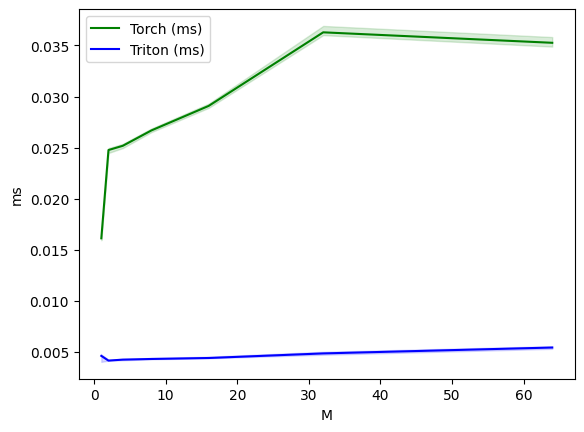

Quantize-performance-decoding:
      M  Torch (ms)  Triton (ms)
0   1.0    0.016128     0.004624
1   2.0    0.024768     0.004160
2   4.0    0.025184     0.004256
3   8.0    0.026688     0.004320
4  16.0    0.029088     0.004416
5  32.0    0.036288     0.004864
6  64.0    0.035264     0.005440


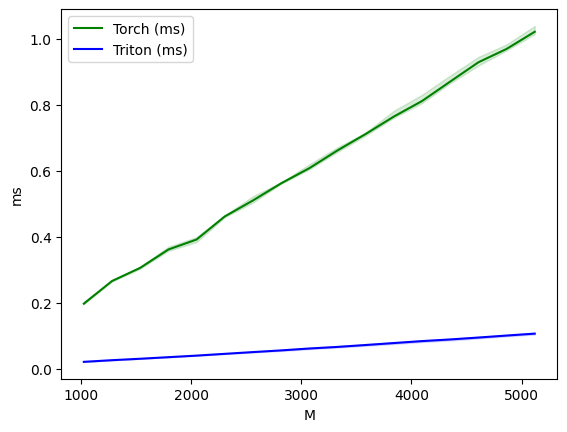

Quantize-performance-prefill:
         M  Torch (ms)  Triton (ms)
0   1024.0    0.197520     0.021504
1   1280.0    0.266160     0.026496
2   1536.0    0.306000     0.030864
3   1792.0    0.361568     0.035584
4   2048.0    0.391776     0.040352
5   2304.0    0.461568     0.045696
6   2560.0    0.509984     0.051008
7   2816.0    0.561824     0.056128
8   3072.0    0.607648     0.061856
9   3328.0    0.661456     0.066688
10  3584.0    0.711200     0.072464
11  3840.0    0.764016     0.078400
12  4096.0    0.810992     0.084320
13  4352.0    0.869888     0.089280
14  4608.0    0.928240     0.095040
15  4864.0    0.968736     0.101088
16  5120.0    1.020704     0.106944


In [ ]:
configs = [
    triton.testing.Benchmark(
        x_names=["M"],  # Argument names to use as an x-axis for the plot
        x_vals=[2 ** i for i in range(7)],  # Different possible values for `x_name`
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        # Possible values for `line_arg`
        line_vals=["torch", "triton"],  # Label name for the lines
        line_names=["Torch", "Triton"],  # Line styles
        styles=[("green", "-"), ("blue", "-")],
        ylabel="ms",  # Label name for the y-axis
        plot_name="Quantize-performance-" + ("decoding"),  # Name for the plot, used also as a file name for saving the plot.
        args={"provider_funcs": provider_funcs},
    ),
    triton.testing.Benchmark(
        x_names=["M"],  # Argument names to use as an x-axis for the plot
        x_vals=[256 * i for i in range(4, 21)],  # Different possible values for `x_name`
        line_arg="provider",  # Argument name whose value corresponds to a different line in the plot
        # Possible values for `line_arg`
        line_vals=["torch", "triton"],  # Label name for the lines
        line_names=["Torch", "Triton"],  # Line styles
        styles=[("green", "-"), ("blue", "-")],
        ylabel="ms",  # Label name for the y-axis
        plot_name="Quantize-performance-" + ("prefill"),  # Name for the plot, used also as a file name for saving the plot.
        args={"provider_funcs": provider_funcs},
    ),
]


triton.testing.perf_report(configs)(benchmark).run(show_plots=True, print_data=True)

**Note:** The PyTorch implementation for quantization is extremely inefficient and Triton quantization performs significantly better on both prefill and decode

### Bonus task: SmoothQuant (3 points)

Your task is to use your implementation of dynamic w8a8 GeMM for real-world LLM inference speedup. Read the paper below and implement the algorithm:
1. Smooth your model. You may want to write custom triton kernel for fast activation smoothing in runtime (or leave it in torch).
2. After that validate the model quality (e.g. perplexity).
3. Create `W8A8Linear` module, which smooths and dynamically quantizes activations and performs quantized GeMM with already smoothed and quantized INT8 weights.
4. Replace all linear layers with `W8A8Linear` (quantize your smoothed weight).
5. Validate quantized model. Your should experience no drop in quality.
6. Measure end-to-end speedup.
7. 🤝🏻 Get my personal respect

Resources:
- https://arxiv.org/abs/2211.10438
- [SmoothQuant repo](https://github.com/mit-han-lab/smoothquant)

### Vanilla SpecDec (4 points)

_Special thanks to @hawkeoni for this part of HW._

In [ ]:
# You might want to reload the notebook. In such case, run this cell.
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Using device", device)

#### Init

In [ ]:
if True:
    name_big = "unsloth/Llama-3.2-3B-Instruct"
    name_small = "unsloth/Llama-3.2-1B-Instruct"
else:
    name_big = "openai-community/gpt2-medium"
    name_small = "openai-community/gpt2"

model_3b = AutoModelForCausalLM.from_pretrained(name_big).to(device)
model_1b = AutoModelForCausalLM.from_pretrained(name_small).to(device)


tokenizer = AutoTokenizer.from_pretrained(name_big)

In [ ]:
prompt = """
# SYSTEM PREAMBLE
1) You are an excellent Python software developer with over 10 years of experience. You have a strong understanding of Python related topics, data structures, libraries, frameworks, algorithms, best practices and optimization techniques.
2) You are here to help the user (the software developer) by breaking his request in ## TASK into logical steps and writing high-quality and efficient code to implement each step.
3) You have to return the entire code.
4) Follow "Answering rules" without exception.

## ANSWERING RULES
1) Repeat the question before answering it.
2) Always follow "CHAIN OF THOUGHTS" to execute the task.

## CHAIN OF THOUGHTS
1) **OBEY the EXECUTION MODE**
2) **TASK ANALYSIS:**
   - Understand the user's request thoroughly.
   - Identify the key components and requirements of the task.
3) **PLANNING: CODDING:**
   - Break down the task into logical, sequential steps.
   - Outline the strategy for implementing each step.
4) **CODING:**
   - Explain your thought process before writing any code.
   - Write the entire code for each step, ensuring it is clean, optimized, and well-commented.
   - Handle edge cases and errors appropriately.
5) **VERIFICATION:**
   - Review the complete code solution for accuracy and efficiency.
   - Ensure the code meets all requirements and is free of errors.

## TASK

Write a python function that receives the following JSON as input and enters data from it into the Google Sheet.

{
    'date': '31-05-2024',
    'revenue': 90000,
    'person' : 'User1',
    'expensesList': [30000, 14000, 10000, 2000, 15000],
    'expensesDescList': [ 'Ключи', 'Ключи2', 'Счет за такси', 'Клей, пластины', 'Провод 40м'],
    'expensesTypeList': ['Закупки', 'Закупки', 'Расходы', 'Ремонт', 'Ремонт']
}

There is a date in JSON, you can use it to determine the month.
The data is entered into a list with the name of the month. If such a list does not exist yet, then you need to create a list with a new month inside the sheet.

The list should have the following columns (the first rows are used as headings):
A1: Дата расхода,
B1: сумма расхода,
C1: описание расхода,
D1: тип расхода,
E1: кто внес данные

G1: Дата выручки
H1: Сумма выручки
I1: Кто внес данные

Please separate expenses and profits with a blank column.
Please sort expenses by date, including those already listed in Google sheet list.
Please sort earnings by date, including those already listed in Google sheet list.

It is prohibited to use oauth2client as it is deprecated.
"""

#### Greedy SpecDec (3 points)

In this task, you need to implement speculative decoding in PyTorch. **Generation must be done greedily.**

1. Generate n tokens using the small model
2. Check if the big model would choose these same tokens during greedy generation (only one forward pass of the big model should be called, using big_model.generate is not allowed at this stage)
3. If all tokens are chosen by the big model, accept them and return to step 1
4. If any token is chosen incorrectly, use the correct token from step 2 instead and return to step 1.

**Important note:** your SpecDec must support KV-cache correctly. Suppose you already have $n$ accepted tokens, and you are verifying next $k$ tokens. Large model only has cache for the first $n$ tokens, and must not add the draft token to it's KV-cache yet since they might be rejected. Only when verification is done and you know which tokens are accepted, you can update the KV-cache for the large model. Also, KV-cache of the draft model must be corrected to evict rejected tokens.

In [ ]:
@torch.no_grad()
def speculative_generate(big_model, small_model, prefix: str, max_num_tokens: int, n: int) -> tuple[str, int, int]:
    """Vanilla speculative decoding for greedy generation.

    Args:
        big_model: original big HF model (verifier).
        small_model: small HF model (draft).
        prefix (str): prompt.
        max_num_tokens (int): max tokens to generate.
        n (int): number of tokens to speculate.

    Returns: generated text, number of accepted tokens, number of all tokens.
    """

    input_ids = tokenizer(prefix, return_tensors="pt").input_ids.to(device)
    start_size = input_ids.size(1)
    cnt_accepted = 0
    cnt_all = 0
    while input_ids.size(1) - start_size < max_num_tokens:
        # !!! TASK: Generate a sequence using the small model
        small_generation = 
        num_generated_tokens = 

        # !!! TASK: Check the sequence using the big model
        big_model_logits = 
        big_model_generations = 
        
        mismatch = False
        for i in range(num_generated_tokens):
            # !!! TASK: found a mismatch at position i
            if True:
                mismatch = True
                # !!! TASK: if the first token is incorrect, take the first token predicted by the big model
                if i == 0:
                    input_ids = torch.cat(
                        (), 
                        dim=1
                    )
                # !!! TASK: otherwise take previous tokens predicted by the small model + the correct token from the big model
                else:
                    input_ids = torch.cat(
                        (),
                        dim=1
                    )
                print(f"Accepted {i}/{n} tokens")
                cnt_accepted += i
                cnt_all += n
                break
        
        if not mismatch:
            # !!! TASK: if there was no mismatch, accept the entire sequence + the last token from the big model
            input_ids = torch.cat((), dim=1)
    # !!! TASK: use tokenizer to decode generated ids
    decoded_text = 
    return decoded_text, cnt_accepted, cnt_all

In [ ]:
res_spec, cnt_accepted, cnt_all = speculative_generate(big_model=model_3b, small_model=model_1b, prefix=prompt, max_num_tokens=128, n=2)

In [ ]:
model_inputs = tokenizer([prompt], return_tensors="pt").to(device)
res_big = tokenizer.batch_decode(
    model_3b.generate(**model_inputs, do_sample=False, max_new_tokens=128)[:, model_inputs.input_ids.shape[1]:],
    skip_special_tokens=True
)[0]

In [ ]:
assert res_big == res_spec and len(res_big) == len(res_spec)

In [ ]:
assert cnt_accepted / cnt_all > 0.19

#### HF SpecDec (1 point)

Now try using the speculative decoding function from [transformers](https://huggingface.co/docs/transformers/main/en/generation_strategies#speculative-decoding)

In [ ]:
import time

# !!! TASK: generate with assistant_model and compare with big model inference time
inputs = 
max_new_tokens = 256

# SpecDec from HF
start = 
outputs = 
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))
print(f"Elapsed time for speculative {}")

# ordinary
start = 
outputs = 
print(tokenizer.batch_decode(outputs, skip_special_tokens=True))
print(f"Elapsed time for big model inference {}")

Make a conclusion about the efficiency of SpecDec implementation in HF.

**Your conclusion:**
- TBD

# Bonus: Sparse KV-cache (1 point)

In [ ]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import json
import math
import random
from dataclasses import dataclass, asdict
from functools import partial
from pathlib import Path
from typing import Dict, List, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from transformers.models.qwen3.modeling_qwen3 import apply_rotary_pos_emb

In [ ]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

In [ ]:
def torch_dtype_from_str(name: str) -> torch.dtype:
    name = name.lower()
    if name == "bfloat16":
        return torch.bfloat16
    if name == "float16":
        return torch.float16
    if name == "float32":
        return torch.float32
    raise ValueError(f"Unsupported dtype: {name}")

# RazorAttention

RazorAttention paper: https://arxiv.org/pdf/2407.15891. It's recommended to read it before the assignmnet.

In this task we will ensure that attention is largely sparse. To that end, we will reproduce an empirical approach to find streaming / retrieval attention heads, and then visualize attention maps for the found head.

**What to do:** in the code below, find and fill `# ! TASK` segments, and then run the code.

In [ ]:
@dataclass
class RazorIDConfig:
    model_name: str = "Qwen/Qwen3-4B-Instruct-2507"
    dtype: str = "bfloat16"           # "float16" or "bfloat16"
    device: str = "cuda"

    # RazorAttention probe settings
    k_random_tokens: int = 2500       # paper example
    repeats: int = 4                  # paper uses 4 repeats
    induction_top_pct: float = 0.14   # top 14%
    echo_top_pct: float = 0.01        # top 1%

    # Compute settings
    chunk_q: int = 64                 # query chunk size for score computation
    score_dtype: str = "float32"      # use float32 for stability in softmax/logits
    save_path: str = "razorattention_qwen3_4b_heads.json"
    
    seed: int = 42

In [ ]:
cfg = RazorIDConfig(seed=1000)

In [ ]:
model_dtype = torch_dtype_from_str(cfg.dtype)
score_dtype = torch_dtype_from_str(cfg.score_dtype)

tokenizer = AutoTokenizer.from_pretrained(cfg.model_name, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    cfg.model_name,
    torch_dtype=model_dtype,
    device_map=None,
    trust_remote_code=True,
).to(cfg.device)
model.eval()

In [ ]:
def repeat_kv(key_states: torch.Tensor, n_rep: int) -> torch.Tensor:
    """
    Repeat kv to match q for GQA:
    input:  [B, num_kv_heads, T, D]
    output: [B, num_q_heads,  T, D], with num_q_heads = num_kv_heads * n_rep
    """

    bsz, num_kv_heads, seqlen, head_dim = key_states.shape
    if n_rep == 1:
        return key_states

    result =   # ! TASK: repeat over second dim
    return result


def sample_unique_non_special_token_ids(
    tokenizer,
    vocab_size: int,
    k: int,
    seed: int,
) -> torch.Tensor:
    """
    Sample unique non-special token IDs to make echo/induction targets unambiguous.
    """

    rng = torch.Generator(device="cpu")
    rng.manual_seed(seed)

    special_ids = set(tokenizer.all_special_ids)
    candidate_ids =   # ! TASK: select non special ids from vocab

    if len(candidate_ids) < k:
        raise ValueError(f"Not enough non-special tokens: requested {k}, have {len(candidate_ids)}")

    perm =   # ! TASK: sample k candidates without repetitions
    picked =   # ! TASK: pick from candidate_ids
    return picked


def build_probe_input(
    tokenizer,
    model,
    k_random_tokens: int,
    repeats: int,
    seed: int,
    device: str,
) -> torch.Tensor:
    vocab_size = model.config.vocab_size
    base = sample_unique_non_special_token_ids(
        tokenizer=tokenizer,
        vocab_size=vocab_size,
        k=k_random_tokens,
        seed=seed,
    )
    full =   # ! TASK: repeat and reshape to [1, T]
    return full


def make_query_and_target_positions(k: int, repeats: int, device: torch.device):
    """
    For query position q in block (of size k) r>0, offset j:
      echo target      = previous block same offset
      induction target = echo target + 1
    """
    query_positions = []
    echo_targets = []
    induction_targets = []

    for r in range(1, repeats):
        for j in range(k):
            q =   # ! TASK: current q index
            echo =   # ! TASK: one block back
            induction =   # ! TASK: next to echo
            query_positions.append(q)
            echo_targets.append(echo)
            induction_targets.append(induction)

    return (
        torch.tensor(query_positions, dtype=torch.long, device=device),
        torch.tensor(echo_targets, dtype=torch.long, device=device),
        torch.tensor(induction_targets, dtype=torch.long, device=device),
    )


@torch.no_grad()
def identify_razor_heads(cfg: RazorIDConfig) -> Dict:
    set_seed(cfg.seed)

    config = model.config
    num_layers = config.num_hidden_layers
    num_q_heads = config.num_attention_heads
    num_kv_heads = config.num_key_value_heads
    num_kv_groups = num_q_heads // num_kv_heads

    input_ids = build_probe_input(
        tokenizer=tokenizer,
        model=model,
        k_random_tokens=cfg.k_random_tokens,
        repeats=cfg.repeats,
        seed=cfg.seed,
        device=cfg.device,
    )
    bs, seq_len = input_ids.shape
    assert bs == 1, "This script assumes batch size 1."

    query_positions, echo_targets, induction_targets = make_query_and_target_positions(
        k=cfg.k_random_tokens,
        repeats=cfg.repeats,
        device=input_ids.device,
    )
    num_probe_queries = query_positions.numel()

    echo_sum = torch.zeros(num_layers, num_q_heads, dtype=torch.float64, device="cpu")
    induction_sum = torch.zeros(num_layers, num_q_heads, dtype=torch.float64, device="cpu")

    # Cache per-layer results from hooks
    def make_pre_hook(layer_idx: int):
        def hook(module, args, kwargs):
            """
            We intercept the normalized hidden_states entering self_attn and reconstruct Q/K
            exactly the way Qwen3Attention.forward does:
              q = q_norm(q_proj(hidden_states))
              k = k_norm(k_proj(hidden_states))
              q, k = apply_rotary_pos_emb(q, k, cos, sin)
            Then we compute the softmax probability assigned to:
              - echo token
              - induction token
            for all probe query positions.
            """
            hidden_states = kwargs["hidden_states"]  # [1, T, hidden]
            cos, sin = kwargs["position_embeddings"]

            input_shape = hidden_states.shape[:-1]
            hidden_shape = (*input_shape, -1, module.head_dim)

            # Shapes:
            # q: [B, num_q_heads,  T, D]
            # k: [B, num_kv_heads, T, D]
            query_states =   # ! TASK: apply q_proj + q_norm
            key_states =   # ! TASK: apply k_proj + k_norm

            query_states, key_states =   # ! TASK aply_rotary_pos_emb
            key_states =   # ! TASK repeat_kv

            # Work in float32 for stable logits/softmax.
            q = query_states.to(score_dtype)
            k = key_states.to(score_dtype)

            T = q.shape[2]
            key_positions = torch.arange(T, device=q.device)

            layer_echo_sum = torch.zeros(num_q_heads, dtype=torch.float64, device=q.device)
            layer_ind_sum = torch.zeros(num_q_heads, dtype=torch.float64, device=q.device)

            for start in range(0, num_probe_queries, cfg.chunk_q):
                end = min(start + cfg.chunk_q, num_probe_queries)
                q_pos = query_positions[start:end]
                e_pos = echo_targets[start:end]
                i_pos = induction_targets[start:end]

                # q_chunk: [B, H, Q, D]
                q_chunk = q[:, :, q_pos, :]

                # logits: [B, H, Q, T]
                logits =   # ! TASK multiply q_chunk with k (don't forget the transpose) and apply module.scaling

                # ! TASK: causal masking: keys > query_position are illegal
                causal_bad =   # [Q, T]
                logits = logits.masked_fill(causal_bad.unsqueeze(0).unsqueeze(0), float("-inf"))

                probs = F.softmax(logits, dim=-1, dtype=torch.float32)  # [1, H, Q, T]

                # Gather target probabilities
                # Shapes after gather: [1, H, Q]
                echo_probs = probs.gather(
                    dim=-1,
                    index=e_pos.view(1, 1, -1, 1).expand(1, num_q_heads, -1, 1)
                ).squeeze(-1)
                induction_probs = probs.gather(
                    dim=-1,
                    index=i_pos.view(1, 1, -1, 1).expand(1, num_q_heads, -1, 1)
                ).squeeze(-1)

                # Sum across Q, keep H
                layer_echo_sum += echo_probs[0].sum(dim=-1).to(torch.float64)
                layer_ind_sum += induction_probs[0].sum(dim=-1).to(torch.float64)

            echo_sum[layer_idx] += layer_echo_sum.cpu()
            induction_sum[layer_idx] += layer_ind_sum.cpu()

            # Return None so the actual forward proceeds unchanged.
            return None

        return hook

    handles = []
    for layer_idx, layer in enumerate(model.model.layers):
        # Hook the self-attention module *before* it computes attention.
        h = layer.self_attn.register_forward_pre_hook(make_pre_hook(layer_idx), with_kwargs=True)
        handles.append(h)

    try:
        _ = model(
            input_ids=input_ids,
            use_cache=False,
        )
    finally:
        for h in handles:
            h.remove()

    echo_scores = echo_sum / num_probe_queries            # [L, H]
    induction_scores = induction_sum / num_probe_queries  # [L, H]

    total_query_heads = num_layers * num_q_heads
    n_echo = max(1, math.ceil(total_query_heads * cfg.echo_top_pct))
    n_ind = max(1, math.ceil(total_query_heads * cfg.induction_top_pct))

    flat_echo = echo_scores.view(-1)
    flat_ind = induction_scores.view(-1)

    _, top_echo_idx =   # ! TASK: select top echo idxs from flat_echo
    _, top_ind_idx =   # ! TASK: select top induction idxs from flat_ind

    echo_query_heads = sorted(
        
    )  # ! TASK: convert from idx to layer_idx + head_idx
    induction_query_heads = sorted(
        
    )  # ! TASK: convert from idx to layer_idx + head_idx
    retrieval_query_heads =   # ! TASK: union echo and induction query heads (and sort the result)

    # GQA promotion rule from RazorAttention:
    # if any query head in a KV-sharing group is retrieval, mark the full KV group retrieval.
    retrieval_kv_groups = set()
    for layer_idx, q_head in retrieval_query_heads:
        kv_group =   # ! TASK: q_head -> kv_group
        retrieval_kv_groups.add((layer_idx, kv_group))
    retrieval_kv_groups = sorted(retrieval_kv_groups)

    # Helpful reverse map: KV group -> query heads
    kv_group_to_query_heads = {}
    for kv_idx in range(num_kv_heads):
        q_start =   # ! TASK: kv_idx -> q_start
        q_end =   # ! TASK: kv_idx -> q_end
        kv_group_to_query_heads[kv_idx] = list(range(q_start, q_end))

    result = {
        "config": asdict(cfg),
        "thresholds": {
            "echo_top_pct": cfg.echo_top_pct,
            "induction_top_pct": cfg.induction_top_pct,
            "n_echo_query_heads": n_echo,
            "n_induction_query_heads": n_ind,
        },
        "echo_query_heads": [
            {"layer": l, "q_head": h, "score": float(echo_scores[l, h].item())}
            for l, h in echo_query_heads
        ],
        "induction_query_heads": [
            {"layer": l, "q_head": h, "score": float(induction_scores[l, h].item())}
            for l, h in induction_query_heads
        ],
        "retrieval_query_heads_union": [
            {
                "layer": l,
                "q_head": h,
                "echo_score": float(echo_scores[l, h].item()),
                "induction_score": float(induction_scores[l, h].item()),
                "kv_group": int(h // num_kv_groups),
            }
            for l, h in retrieval_query_heads
        ],
        "retrieval_kv_groups": [
            {
                "layer": l,
                "kv_group": kv,
                "query_heads_in_group": kv_group_to_query_heads[kv],
            }
            for l, kv in retrieval_kv_groups
        ],
        "all_scores": {
            "echo_scores": echo_scores.tolist(),
            "induction_scores": induction_scores.tolist(),
        },
    }

    save_path = Path(cfg.save_path)
    save_path.write_text(json.dumps(result, indent=2))
    print(f"Saved results to: {save_path.resolve()}")
    print(f"Probe length: {seq_len}")
    print(f"Selected echo query heads: {len(echo_query_heads)}")
    print(f"Selected induction query heads: {len(induction_query_heads)}")
    print(f"Selected retrieval query heads (union): {len(retrieval_query_heads)}")
    print(f"Selected retrieval KV groups after GQA promotion: {len(retrieval_kv_groups)}")

    return result

In [ ]:
result = identify_razor_heads(cfg)

# TESTS
assert 75 >= len(result["retrieval_kv_groups"]) >= 65, f"{len(result["retrieval_kv_groups"])}"
assert {'layer': 2, 'kv_group': 7, 'query_heads_in_group': [28, 29, 30, 31]} in result["retrieval_kv_groups"]
assert {'layer': 9, 'kv_group': 2, 'query_heads_in_group': [8, 9, 10, 11]} in result["retrieval_kv_groups"]
assert {'layer': 9, 'kv_group': 4, 'query_heads_in_group': [16, 17, 18, 19]} in result["retrieval_kv_groups"]

In [ ]:
print("Top 10 retrieval KV groups:")
for row in result["retrieval_kv_groups"][:10]:
    print(row)

# Visualization

In [ ]:
@dataclass
class VizConfig:
    razor_json_path: str = "razorattention_qwen3_4b_heads.json"
    device: str = "cuda"
    dtype: str = "bfloat16"

    prompt: str = ""

    max_new_tokens: int = 100
    do_sample: bool = False
    temperature: float = 1.
    local_window: int = 32
    max_x_tokens_to_label: int = 80

    # topk heads for plots
    top_k_heads: int = 5

    # size of one subplot row
    heatmap_figsize_per_plot: Tuple[int, int] = (14, 4)
    profile_figsize_per_plot: Tuple[int, int] = (14, 2)

In [ ]:
def load_razor_head_sets(path: str):
    data = json.loads(Path(path).read_text())

    echo_heads = {
        (row["layer"], row["q_head"]): row["score"]
        for row in data.get("echo_query_heads", [])
    }

    induction_heads = {
        (row["layer"], row["q_head"]): row["score"]
        for row in data.get("induction_query_heads", [])
    }

    all_echo = np.array(data["all_scores"]["echo_scores"])
    all_ind = np.array(data["all_scores"]["induction_scores"])

    return data, echo_heads, induction_heads, all_echo, all_ind

In [ ]:
@torch.no_grad()
def generate_with_attention_trace(
    model,
    tokenizer,
    prompt: str,
    max_new_tokens: int,
    device: str,
):
    """Greedy sampling with trace capture."""

    inputs = tokenizer(prompt, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    prompt_len = input_ids.shape[1]
    past_key_values = None
    generated_ids = input_ids
    trace = []

    cur_input_ids = input_ids
    cur_attention_mask = attention_mask

    for _ in range(max_new_tokens):
        outputs = model(
            input_ids=cur_input_ids,
            attention_mask=cur_attention_mask,
            past_key_values=past_key_values,
            use_cache=True,
            output_attentions=True,
            return_dict=True,
        )

        logits = outputs.logits[:, -1, :]
        next_token = torch.argmax(logits, dim=-1, keepdim=True)

        token_id = int(next_token.item())

        trace.append(
            {
                "token_id": token_id,
                "token_text": tokenizer.decode([token_id], skip_special_tokens=False),
                "attentions": tuple(a.detach().cpu() for a in outputs.attentions),
                "seq_len_after_step": generated_ids.shape[1] + 1,
            }
        )

        generated_ids = torch.cat([generated_ids, next_token], dim=-1)
        past_key_values = outputs.past_key_values

        cur_input_ids = next_token
        cur_attention_mask = torch.cat(
            [cur_attention_mask, torch.ones((1, 1), dtype=cur_attention_mask.dtype, device=device)],
            dim=-1,
        )

        if tokenizer.eos_token_id is not None and token_id == tokenizer.eos_token_id:
            break

    return trace, generated_ids, prompt_len

In [ ]:
def extract_head_decode_map(
    trace: List[Dict],
    layer_idx: int,
    head_idx: int,
) -> np.ndarray:
    rows = []
    max_len = 0

    for step_info in trace:
        attn = step_info["attentions"][layer_idx]   # [1, H, q_len, kv_len]
        row =   # ! TASK: extract by head for last q
        rows.append(row)
        max_len = max(max_len, row.shape[0])

    out = np.zeros((len(rows), max_len), dtype=np.float32)
    for i, row in enumerate(rows):
        out[] = row  # ! TASK: fill out with current row
    return out


def compute_prompt_specific_metrics(
    attn_map: np.ndarray,
    prompt_len: int,
    local_window: int,
) -> Dict[str, float]:
    if attn_map.size == 0:
        return {
            "local_ratio": 0.0,
            "remote_ratio": 0.0,
            "prompt_ratio": 0.0,
            "peakiness": 0.0,
        }

    local_ratios = []
    remote_ratios = []
    prompt_ratios = []
    peaks = []

    for row in attn_map:
        valid_idx = np.nonzero(row > 0)[0]
        if len(valid_idx) == 0:
            continue
        L = valid_idx[-1] + 1
        r =   # ! TASK: extract valid part of the row (under diag)
        s = r.sum()
        if s <= 0:
            continue
          # ! TASK: normalize scores

        local_start = max(0, L - local_window)
        local_ratios.append()  # ! TASK: sum ratios on window starting from local_start
        remote_ratios.append()  # ! TASK: sum ratios on window ending from local_start
        prompt_ratios.append()  # ! TASK: sum ratios on prompt
        peaks.append(float(r.max()))  # ! TASK: add max score

    if not local_ratios:
        return {
            "local_ratio": 0.0,
            "remote_ratio": 0.0,
            "prompt_ratio": 0.0,
            "peakiness": 0.0,
        }

    return {
        "local_ratio": float(np.mean(local_ratios)),
        "remote_ratio": float(np.mean(remote_ratios)),
        "prompt_ratio": float(np.mean(prompt_ratios)),
        "peakiness": float(np.mean(peaks)),
    }

In [ ]:
def rank_heads_for_prompt(
    trace: List[Dict],
    prompt_len: int,
    num_layers: int,
    num_heads: int,
    echo_heads: Dict[Tuple[int, int], float],
    induction_heads: Dict[Tuple[int, int], float],
    local_window: int,
):
    all_metrics = {}
    all_maps = {}

    for layer in range(num_layers):
        for head in range(num_heads):
            m = extract_head_decode_map(trace, layer, head)
            all_maps[(layer, head)] = m
            all_metrics[(layer, head)] = compute_prompt_specific_metrics(m, prompt_len, local_window)

    echo_set = set(echo_heads.keys())
    induction_set = set(induction_heads.keys())
    special_set = echo_set | induction_set

    # streaming = heads outside RazorAttention's echo/induction-selected sets
    non_special = [lh for lh in all_metrics if lh not in special_set]
    streaming_ranked = sorted(
        non_special if non_special else list(all_metrics.keys()),
        key=lambda lh: (
            +/-all_metrics[lh]["local_ratio"],  # ! TASK: select correct sign
            +/-all_metrics[lh]["remote_ratio"],  # ! TASK: select correct sign
            +/-all_metrics[lh]["peakiness"],  # ! TASK: select correct sign
        ),
        reverse=True,
    )
    # retrieval
    echo_ranked = sorted(
        list(echo_set),
        key=lambda lh: (
            +/-all_metrics[lh]["remote_ratio"],  # ! TASK: select correct sign
            +/-all_metrics[lh]["peakiness"],  # ! TASK: select correct sign
            +/-echo_heads[lh],  # ! TASK: select correct sign
        ),
        reverse=True,
    )
    induction_ranked = sorted(
        list(induction_set),
        key=lambda lh: (
            +/-all_metrics[lh]["remote_ratio"],  # ! TASK:  select correct sign
            +/-all_metrics[lh]["peakiness"],  # ! TASK: select correct sign
            +/-induction_heads[lh],  # ! TASK: select correct sign
        ),
        reverse=True,
    )

    return streaming_ranked, echo_ranked, induction_ranked, all_metrics, all_maps

In [ ]:
PROMPT = """[System]
You are a customer-support assistant for a travel booking platform.
Answer ONLY from the provided retrieved notes.
If the notes do not contain the answer, say: "I don’t have enough information from the retrieved notes."
Be careful with pronouns like "it", "that hotel", and "the cheaper one".

[Retrieved note A]
Hotel Alder is a 4-star property near Riverside Station.
Check-in starts at 15:00.
Breakfast is included only in the Flex and Business rates.
Standard rate is non-refundable.
Airport shuttle runs every 30 minutes from 06:00 to 22:00.

[Retrieved note B]
Hotel Birch is a 3-star property near the old town.
Check-in starts at 14:00.
Breakfast is never included.
Standard and Flex rates are both refundable up to 24 hours before arrival.
No airport shuttle is available.

[Retrieved note C]
Important exception: for bookings made during the “Spring Rail Bundle” campaign,
Hotel Alder Flex becomes refundable up to 48 hours before arrival.
This exception does NOT change breakfast rules.

[Retrieved note D]
Noise disclaimer: Riverside Station undergoes track maintenance on Tuesdays and Thursdays.
Guests sensitive to noise often prefer Birch, although Birch rooms are smaller.

[Conversation]
User: I’m choosing between Alder and Birch for a Tuesday night. I care about breakfast and a shuttle.
Assistant: Alder has a shuttle and may include breakfast depending on rate; Birch has no shuttle and never includes breakfast.
User: Okay, and which one is usually quieter?
Assistant: For a Tuesday night, Birch is usually quieter because of Riverside maintenance near Alder.
User: Suppose I book the refundable option at the one with the shuttle during the Spring Rail Bundle. Can I still cancel, and does it include breakfast?
Assistant: """

In [ ]:
cfg = VizConfig(
    prompt=PROMPT,
    top_k_heads=5,
)

razor_data, echo_heads, induction_heads, all_echo, all_ind = load_razor_head_sets(cfg.razor_json_path)

trace, full_ids, prompt_len = generate_with_attention_trace(
    model=model,
    tokenizer=tokenizer,
    prompt=cfg.prompt,
    max_new_tokens=cfg.max_new_tokens,
    device=cfg.device,
)

full_tokens = tokenizer.convert_ids_to_tokens(full_ids[0].tolist())

streaming_ranked, echo_ranked, induction_ranked, all_metrics, all_maps = rank_heads_for_prompt(
    trace=trace,
    prompt_len=prompt_len,
    num_layers=model.config.num_hidden_layers,
    num_heads=model.config.num_attention_heads,
    echo_heads=echo_heads,
    induction_heads=induction_heads,
    local_window=cfg.local_window,
)

topk_streaming = streaming_ranked[: cfg.top_k_heads]
topk_echo = echo_ranked[: cfg.top_k_heads]
topk_induction = induction_ranked[: cfg.top_k_heads]

print("Generated text:\n")
print(tokenizer.decode(full_ids[0][prompt_len:], skip_special_tokens=False))
print(f"\nTop-{cfg.top_k_heads} streaming:", topk_streaming)
print(f"Top-{cfg.top_k_heads} echo:", topk_echo)
print(f"Top-{cfg.top_k_heads} induction:", topk_induction)

In [ ]:
def plot_head_group_heatmaps_inline(
    head_list: List[Tuple[int, int]],
    head_type_name: str,
    all_maps: Dict[Tuple[int, int], np.ndarray],
    all_metrics: Dict[Tuple[int, int], Dict[str, float]],
    full_tokens: List[str],
    prompt_len: int,
    max_x_tokens_to_label: int = 80,
    figsize_per_plot: Tuple[int, int] = (14, 4),
):
    n = len(head_list)
    if n == 0:
        print(f"No heads available for {head_type_name}.")
        return

    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(figsize_per_plot[0], figsize_per_plot[1] * n),
        squeeze=True,
        constrained_layout=True,
    )
    if n == 1:
        axes = [axes]

    vmax = max(float(all_maps[lh].max()) for lh in head_list)
    vmax = vmax if vmax > 0 else None

    def _pretty_token(tok: str) -> str:
        tok = tok.replace("\n", "\\n")
        return tok
    
    im = None
    for ax, (layer, head) in zip(axes, head_list):
        attn_map = all_maps[(layer, head)]
        metrics = all_metrics[(layer, head)]

        im = ax.imshow(
            attn_map,
            aspect="auto",
            interpolation="nearest",
            vmin=0.0,
            vmax=vmax,
            origin="upper",
        )
        ax.axvline(prompt_len - 0.5, linestyle="--", linewidth=1)
        ax.set_title(
            f"{head_type_name} | L{layer} H{head} | "
            f"local={metrics['local_ratio']:.2f} remote={metrics['remote_ratio']:.2f}",
            fontsize=10,
        )
        ax.set_xlabel("Attended token position")
        ax.set_ylabel("Generation step")

        total_len = attn_map.shape[1]
        if total_len <= max_x_tokens_to_label:
            x = np.arange(total_len)
            labels = [_pretty_token(t) for t in full_tokens[:total_len]]
            ax.set_xticks(x)
            ax.set_xticklabels(labels, rotation=90, fontsize=7)

    cbar = fig.colorbar(im, ax=axes, pad=0.02, shrink=0.96)
    cbar.set_label("attention")

    fig.suptitle(f"{head_type_name}: decode heatmaps", fontsize=13)
    plt.show()
    

def plot_head_group_profiles_inline(
    head_list: List[Tuple[int, int]],
    head_type_name: str,
    all_maps: Dict[Tuple[int, int], np.ndarray],
    all_metrics: Dict[Tuple[int, int], Dict[str, float]],
    prompt_len: int,
    local_window: int,
    figsize_per_plot: Tuple[int, int] = (14, 2.5),
):
    n = len(head_list)
    if n == 0:
        print(f"No heads available for {head_type_name}.")
        return

    fig, axes = plt.subplots(
        nrows=n,
        ncols=1,
        figsize=(figsize_per_plot[0], figsize_per_plot[1] * n),
        squeeze=True,
        sharex=False,
        sharey=True,
        constrained_layout=True,
    )
    if n == 1:
        axes = [axes]

    for ax, (layer, head) in zip(axes, head_list):
        attn_map = all_maps[(layer, head)]
        mean_profile = attn_map.mean(axis=0)
        metrics = all_metrics[(layer, head)]

        ax.plot(mean_profile)
        ax.axvline(prompt_len - 0.5, linestyle="--", linewidth=1, label="prompt boundary")
        ax.axvline(
            max(0, len(mean_profile) - local_window) - 0.5,
            linestyle=":",
            linewidth=1,
            label="local window",
        )
        ax.set_title(
            f"{head_type_name} | L{layer} H{head} | peak={metrics['peakiness']:.2f}",
            fontsize=10,
        )
        ax.set_xlabel("Token position")
        ax.set_ylabel("Mean attention")

    axes[0].legend(loc="upper right", fontsize=8)
    fig.suptitle(f"{head_type_name}: mean attention profiles", fontsize=13)
    plt.show()


plot_heatmaps_helper = partial(
    plot_head_group_heatmaps_inline, 
    all_maps=all_maps,
    all_metrics=all_metrics,
    full_tokens=full_tokens,
    prompt_len=prompt_len,
    max_x_tokens_to_label=cfg.max_x_tokens_to_label,
    figsize_per_plot=cfg.heatmap_figsize_per_plot
)
plot_profiles_helper = partial(
    plot_head_group_profiles_inline,
    all_maps=all_maps,
    all_metrics=all_metrics,
    prompt_len=prompt_len,
    local_window=cfg.local_window,
    figsize_per_plot=cfg.profile_figsize_per_plot,
)

In [ ]:
plot_heatmaps_helper(
    head_list=topk_streaming,
    head_type_name=f"Top-{cfg.top_k_heads} Streaming heads",
)
plot_heatmaps_helper(
    head_list=topk_echo,
    head_type_name=f"Top-{cfg.top_k_heads} Echo heads",
)
plot_heatmaps_helper(
    head_list=topk_induction,
    head_type_name=f"Top-{cfg.top_k_heads} Induction heads",
)

**Question:** what's visually different between different types of attention heads?

Your answer:

In [ ]:
plot_profiles_helper(
    head_list=topk_streaming,
    head_type_name=f"Top-{cfg.top_k_heads} Streaming heads",
)
plot_profiles_helper(
    head_list=topk_echo,
    head_type_name=f"Top-{cfg.top_k_heads} Echo heads",
)
plot_profiles_helper(
    head_list=topk_induction,
    head_type_name=f"Top-{cfg.top_k_heads} Induction heads",
)

**Question:** how heads' profiles behave?

Your answer: